In [111]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
'''here we have im ported csv file but there is encoded isuued which solved '''

listings = pd.read_csv(r"C:\Users\Ahasan Hasan\Desktop\Portfolio\Airbnb+Data\Airbnb Data\Listings.csv",
    encoding="ISO-8859-1",
    low_memory=False,
    parse_dates=['host_since']) ## fantastic, I can change data type when do loading

listings.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [6]:
''''# info() provides name and data types of all column
listings.info()
# Now I would like to change data type for response_since because it is in string type

listings['host_since'] = pd.to_datetime(listings['host_since'])'''

listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  str           
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[us]
 4   host_location                278872 non-null  str           
 5   host_response_time           150930 non-null  str           
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  str           
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  str           
 11  host_identity_verified       279547 n

In [7]:
#maven solution
paris_listing = (listings.query("city == 'Paris'")
.loc[:,
['host_since','neighbourhood','city','accommodates','price']])

# my solution
listings_city_1 = (listings
.loc[listings['city'] == 'Paris',
['host_since','neighbourhood','city','accommodates','price']])

listings_city_1.info()

<class 'pandas.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     64657 non-null  datetime64[us]
 1   neighbourhood  64690 non-null  str           
 2   city           64690 non-null  str           
 3   accommodates   64690 non-null  int64         
 4   price          64690 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 3.0 MB


In [8]:
# How many null values we have here, we can measure by isna method
paris_listing.isna().sum()

host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

In [9]:
paris_listing.describe()
paris_listing.head()

,host_since,neighbourhood,city,accommodates,price
0,2011-12-03,Buttes-Montmartre,Paris,2,53
1,2013-11-29,Buttes-Montmartre,Paris,2,120
2,2014-07-31,Elysee,Paris,2,89
3,2013-12-17,Vaugirard,Paris,2,58
4,2014-12-14,Passy,Paris,2,60


In [10]:
p = paris_listing.query("price == 0 and accommodates == 0").count()
print(p)
'''p_1 = paris_listing.query("price > 2000").loc[:,['city','price']] # Extra, to filter out more than 2000 price
print(p_1)'''


host_since       54
neighbourhood    54
city             54
accommodates     54
price            54
dtype: int64


'p_1 = paris_listing.query("price > 2000").loc[:,[\'city\',\'price\']] # Extra, to filter out more than 2000 price\nprint(p_1)'

In [11]:
# Objective 2
'''
1. Create a table named paris_listings_neighbourhood that groups Paris listings by 'neighbourhood' and calculates the mean price (sorted low to high)
2. Create a table named paris_listings_accomodations, filter down to the most expensive neighborhood, group by the ‘accommodations’ column, and add the mean price for each value of ‘accommodates’ (sorted low to high)
3. Create a table called paris_listings_over_time grouped by the ‘host_since’ year, and calculate the average price and count of rows representing the number of new hosts'''


"\n1. Create a table named paris_listings_neighbourhood that groups Paris listings by 'neighbourhood' and calculates the mean price (sorted low to high)\n2. Create a table named paris_listings_accomodations, filter down to the most expensive neighborhood, group by the ‘accommodations’ column, and add the mean price for each value of ‘accommodates’ (sorted low to high)\n3. Create a table called paris_listings_over_time grouped by the ‘host_since’ year, and calculate the average price and count of rows representing the number of new hosts"

                       price
neighbourhood               
Menilmontant       74.942257
Buttes-Chaumont    82.690182
Buttes-Montmartre  87.209479
Reuilly            89.058402
Popincourt         90.559459
                     price
neighbourhood             
Luxembourg      155.638639
Palais-Bourbon  156.856578
Passy           161.144635
Louvre          175.379972
Elysee          210.536765


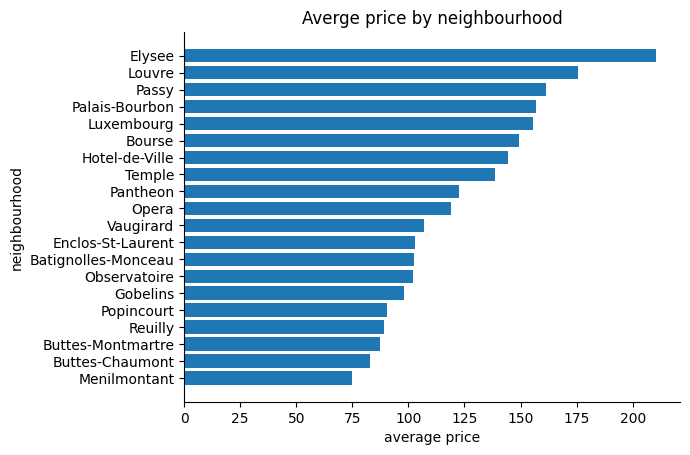

In [104]:
#1. Create a table named paris_listings_neighbourhood that groups Paris listings by 'neighbourhood' and calculates the mean price (sorted low to high)

paris_listings_neighbourhood = (
    paris_listing.groupby('neighbourhood')
    .agg({"price": "mean"})
    .sort_values("price")

)

print(paris_listings_neighbourhood.head())
print(paris_listings_neighbourhood.tail())



plt.title('Averge price by neighbourhood')
plt.xlabel('average price')
plt.ylabel('neighbourhood')
plt.barh(paris_listings_neighbourhood.index,
         paris_listings_neighbourhood["price"])

sns.despine()






<Axes: xlabel='price', ylabel='neighbourhood'>

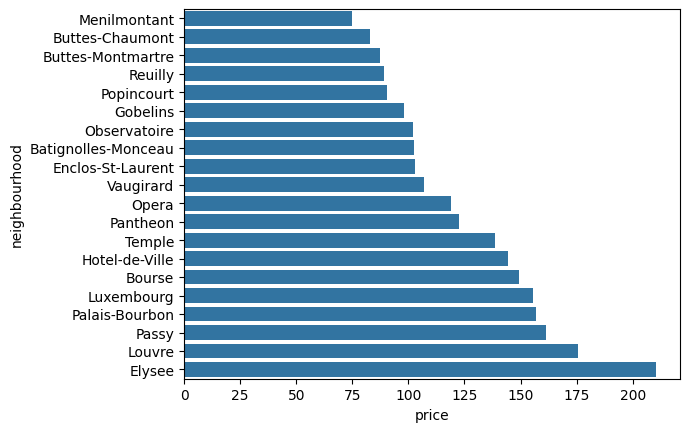

In [13]:
sns.barplot(data=paris_listings_neighbourhood,x = paris_listings_neighbourhood["price"], y = paris_listings_neighbourhood.index)


                   price
accommodates            
0               0.000000
1              79.522222
3             152.828767
2             155.103352
4             212.096070
                price
accommodates         
12            529.625
16            800.000
11            805.000
13            842.500
14            971.000


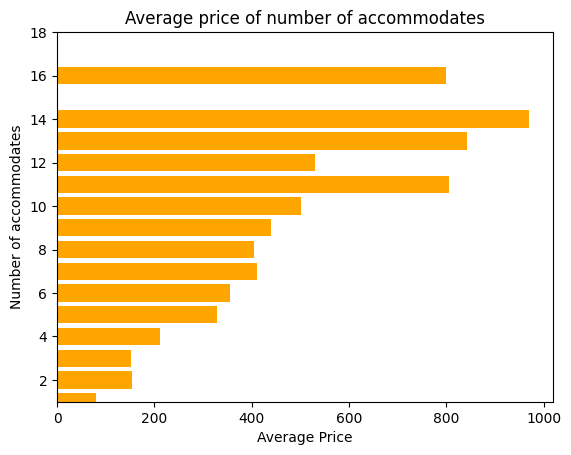

In [14]:
# 2. Create a table named paris_listings_accomodations, filter down to the most expensive neighborhood, group by the ‘accommodations’ column, and add the mean price for each value of ‘accommodates’ (sorted low to high)

paris_listings_accomodations = (paris_listing.query("neighbourhood == 'Elysee'")
                                .groupby("accommodates")
                                .agg({"price": "mean"})
                                .sort_values("price"))

print(paris_listings_accomodations.head())
print(paris_listings_accomodations.tail())





plt.ylim(1,18)
plt.barh(paris_listings_accomodations.index,paris_listings_accomodations["price"], color = 'orange')
plt.title('Average price of number of accommodates')
plt.ylabel('Number of accommodates')
plt.xlabel('Average Price')

plt.show()

In [93]:
#3. Create a table called paris_listings_over_time grouped by the ‘host_since’ year, and calculate the average price and count of rows representing the number of new hosts

paris_listings_over_time = (
    paris_listing.set_index("host_since")
    .resample("YE")
    .agg({
        "neighbourhood":"count",
        "price": "mean"}))

paris_listings_over_time.head()


,neighbourhood,price
host_since,,
2008-12-31,4,77.750000
2009-12-31,106,159.641509
2010-12-31,416,125.031250
2011-12-31,1339,124.828230
2012-12-31,4592,111.578615


In [106]:
paris_listings_over_time = (
    paris_listing.set_index("host_since")
    .resample("YE")
    .agg({
        "neighbourhood": "count",
        "price": "mean"
    })
)
paris_listings_over_time.head()


,neighbourhood,price
host_since,,
2008-12-31,4,77.750000
2009-12-31,106,159.641509
2010-12-31,416,125.031250
2011-12-31,1339,124.828230
2012-12-31,4592,111.578615


In [ ]:
'''Visualize the data and summarize findings
Your final objective is to build visuals to show the number of new hosts by year, overall average price by year and neighborhood, and average price for various types of listings in Paris' most expensive neighborhood.

1. Create a horizontal bar chart of the average price by neighborhood in Paris, and make sure to add a title and change axis labels as needed

2. Create a horizontal bar chart of the average price by ‘accommodates’ in Paris’ most expensive neighborhood, and make sure to add a title and change axis labels as needed

3. Create two line charts: one showing the count of new hosts over time, and one showing average price. Set the y-axis limit to 0, add a title, and change axis labels as needed

4. Based on your findings, what insights do you have about the impact of the 2015 regulations on new hosts and prices?

5. BONUS: Create a dual axis line chart to show both new hosts and average price over time'''



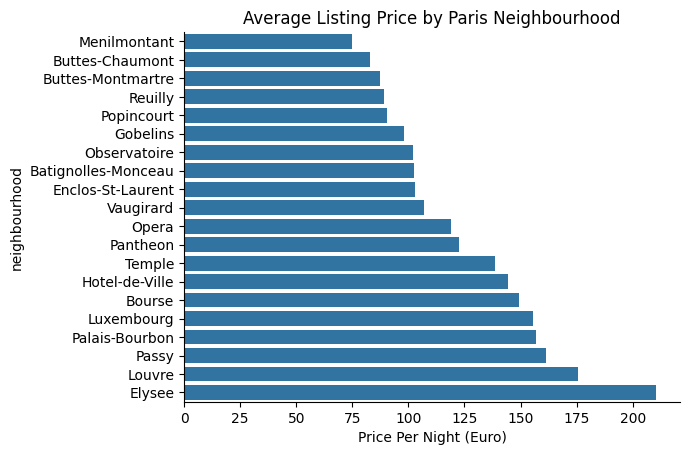

In [21]:
# 1. Create a horizontal bar chart of the average price by neighborhood in Paris, and make sure to add a title and change axis labels as needed
sns.barplot(data=paris_listings_neighbourhood,x = paris_listings_neighbourhood["price"], y = paris_listings_neighbourhood.index)
sns.despine()
plt.title('Average Listing Price by Paris Neighbourhood')
plt.xlabel('Price Per Night (Euro)')
plt.show()



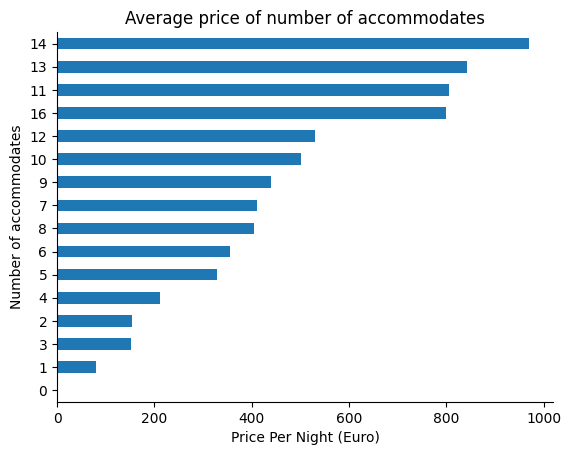

In [31]:
# 2. Create a horizontal bar chart of the average price by ‘accommodates’ in Paris’ most expensive neighborhood, and make sure to add a title and change axis labels as needed

(paris_listings_accomodations.plot.barh(
title='Average price of number of accommodates',
ylabel='Number of accommodates',
xlabel='Price Per Night (Euro)',
legend=None
))
sns.despine()

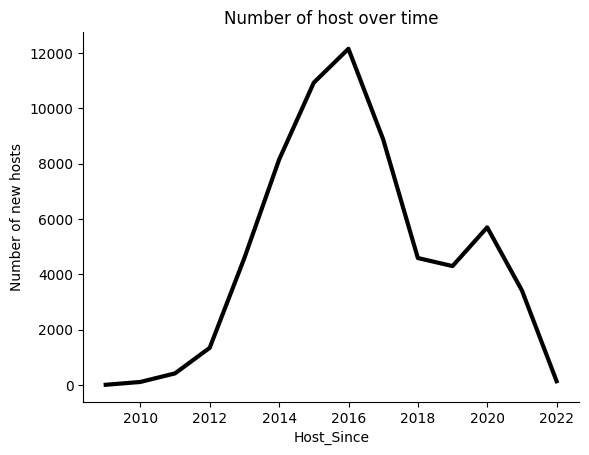

In [100]:
#3. Create two line charts: one showing the count of new hosts over time, and one showing average price. Set the y-axis limit to 0, add a title, and change axis labels as needed

# the count of new hosts over time
plt.xlabel('Host_Since')
plt.ylabel('Number of new hosts')
plt.plot(paris_listings_over_time.index,paris_listings_over_time["neighbourhood"], color = 'black',linewidth = 3)
plt.title('Number of host over time')

sns.despine()
plt.show()


Text(0, 0.5, 'Average price')

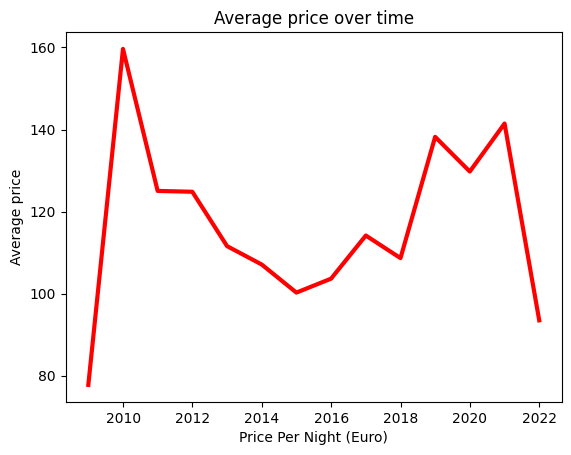

In [110]:
# one showing average price

plt.plot(paris_listings_over_time.index,
         paris_listings_over_time["price"],
         color = 'red',
         linewidth = 3)
plt.title('Average price over time')
plt.xlabel('Price Per Night (Euro)')
plt.ylabel('Average price')

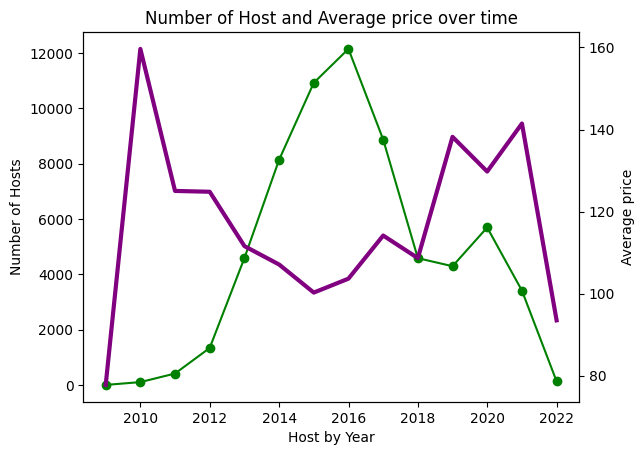

In [108]:
#5.Create a dual axis line chart to show both new hosts and average price over time

import matplotlib.pyplot as plt
import seaborn as sns

ax = plt.subplot()

plt.plot(paris_listings_over_time.index,
         paris_listings_over_time["neighbourhood"],
         color = 'green',
         marker = 'o',

         )
plt.title('Number of Host and Average price over time')
plt.ylabel('Number of Hosts')
plt.xlabel('Host by Year')


ax_2 = plt.twinx()

plt.plot(
    paris_listings_over_time.index,
    paris_listings_over_time["price"],
    color = 'purple',
    linewidth = 3
)

ax_2.set_ylabel('Average price')

plt.show()



In [91]:
# 5. Based on your findings, what insights do you have about the impact of the 2015 regulations on new hosts and prices?
'''Due to new regulation, In 2015 host number was surprisly droped under 3000 while in 2010 it was in peak around 12000 hosts.
'''
